Saving gambar.jpeg to gambar (14).jpeg
Matriks A:
[[223. 191. 110.  95.]
 [221. 206. 160. 126.]
 [220. 214. 168. 156.]
 [219. 218. 167. 148.]]

Transpose A (A^T):
[[223. 221. 220. 219.]
 [191. 206. 214. 218.]
 [110. 160. 168. 167.]
 [ 95. 126. 156. 148.]]

Hasil A * A^T:
[[107335. 118199. 123234. 122905.]
 [118199. 132753. 139240. 138675.]
 [123234. 139240. 146756. 145976.]
 [122905. 138675. 145976. 145278.]]

LANGKAH PERHITUNGAN A * A^T
(1,1) = (223×223) + (191×191) + (110×110) + (95×95) = 107335
(1,2) = (223×221) + (191×206) + (110×160) + (95×126) = 118199
(1,3) = (223×220) + (191×214) + (110×168) + (95×156) = 123234
(1,4) = (223×219) + (191×218) + (110×167) + (95×148) = 122905
(2,1) = (221×223) + (206×191) + (160×110) + (126×95) = 118199
(2,2) = (221×221) + (206×206) + (160×160) + (126×126) = 132753
(2,3) = (221×220) + (206×214) + (160×168) + (126×156) = 139240
(2,4) = (221×219) + (206×218) + (160×167) + (126×148) = 138675
(3,1) = (220×223) + (214×191) + (168×110) + (156×95) = 12323

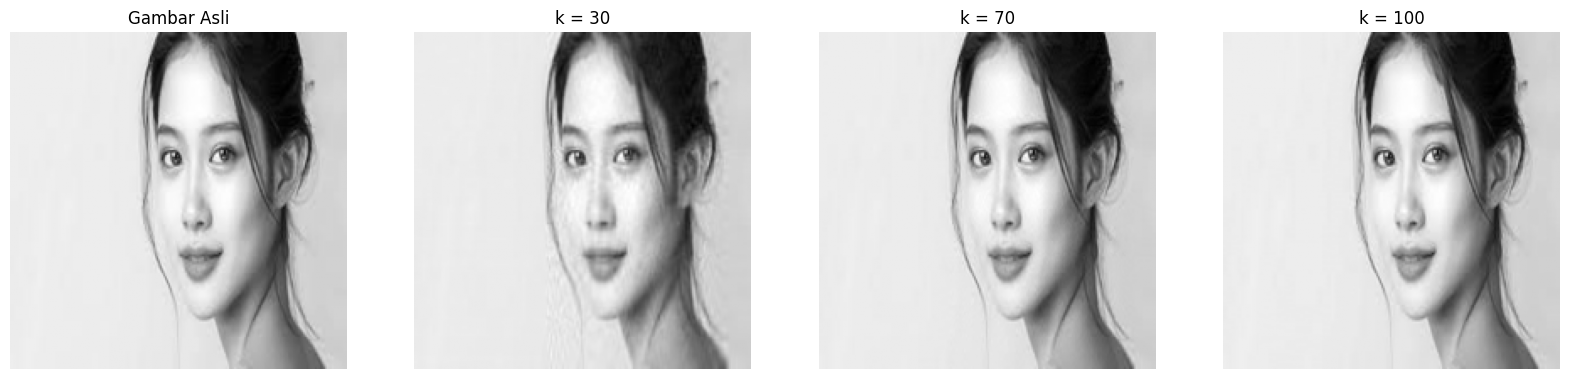

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# =====================================================
# UPLOAD GAMBAR
# =====================================================
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]

# =====================================================
# MEMBACA GAMBAR
# =====================================================
img = Image.open(nama_file)

# Grayscale
img = img.convert("L")

# =====================================================
# GAMBAR ASLI UNTUK DITAMPILKAN
# =====================================================
img_tampil = img.resize((200,200))

A_tampil = np.array(img_tampil, dtype=float)

# =====================================================
# GAMBAR KECIL UNTUK PERHITUNGAN MANUAL
# =====================================================
img_kecil = img.resize((4,4))

A = np.array(img_kecil, dtype=float)

print("Matriks A:")
print(A)

# =====================================================
# TRANSPOSE
# =====================================================
AT = A.T

print("\nTranspose A (A^T):")
print(AT)

# =====================================================
# PERKALIAN A * A^T
# =====================================================
AAT = A @ AT

print("\nHasil A * A^T:")
print(AAT)

# =====================================================
# LANGKAH PERHITUNGAN MANUAL
# =====================================================
print("\n==============================")
print("LANGKAH PERHITUNGAN A * A^T")
print("==============================")

for i in range(A.shape[0]):

    for j in range(AT.shape[1]):

        langkah = []

        total = 0

        for k in range(A.shape[1]):

            angka1 = int(A[i][k])

            angka2 = int(AT[k][j])

            langkah.append(f"({angka1}×{angka2})")

            total += angka1 * angka2

        teks = " + ".join(langkah)

        print(f"({i+1},{j+1}) = {teks} = {int(total)}")

# =====================================================
# NILAI EIGEN
# =====================================================
print("\n==============================")
print("MENCARI NILAI EIGEN")
print("==============================")

eigenvalues, eigenvectors = np.linalg.eig(AAT)

print("\nNilai Eigen:")
print(np.round(eigenvalues,2))

# =====================================================
# VEKTOR EIGEN
# =====================================================
print("\nVektor Eigen:")
print(np.round(eigenvectors,2))

# =====================================================
# SINGULAR VALUE
# =====================================================
print("\n==============================")
print("MENCARI SINGULAR VALUE")
print("==============================")

print("""
Rumus:

σ = √λ

σ = singular value
λ = nilai eigen
""")

singular_values = np.sqrt(eigenvalues)

print("\nSingular Value:")

for i in range(len(singular_values)):

    print(f"σ{i+1} = √{round(eigenvalues[i],2)} = {round(singular_values[i],2)}")

# =====================================================
# MEMBENTUK MATRIKS S
# =====================================================
print("\n==============================")
print("MATRIKS S")
print("==============================")

S = np.zeros((A.shape[0], A.shape[1]))

for i in range(len(singular_values)):

    S[i][i] = singular_values[i]

print(np.round(S,2))

# =====================================================
# MATRIKS U
# =====================================================
print("\n==============================")
print("MATRIKS U")
print("==============================")

U = eigenvectors

print(np.round(U,2))

# =====================================================
# MATRIKS Vt
# =====================================================
print("\n==============================")
print("MATRIKS Vt")
print("==============================")

Vt = np.linalg.inv(S[:A.shape[0], :A.shape[0]]) @ U.T @ A

print(np.round(Vt,2))

# =====================================================
# CEK HASIL SVD
# =====================================================
print("\n==============================")
print("PEMBUKTIAN SVD")
print("==============================")

hasil_svd = U @ S @ Vt

print("\nU × S × Vt =")

print(np.round(hasil_svd,2))

# =====================================================
# SVD UNTUK GAMBAR BESAR
# =====================================================
U_besar, S_besar, Vt_besar = np.linalg.svd(A_tampil, full_matrices=False)

# =====================================================
# FUNGSI REKONSTRUKSI
# =====================================================
def rekonstruksi(k):

    U_k = U_besar[:, :k]

    S_k = np.diag(S_besar[:k])

    Vt_k = Vt_besar[:k, :]

    return U_k @ S_k @ Vt_k

# =====================================================
# REKONSTRUKSI
# =====================================================
A_30 = rekonstruksi(30)

A_70 = rekonstruksi(70)

A_100 = rekonstruksi(100)

# =====================================================
# PERBANDINGAN GAMBAR
# =====================================================
fig, axes = plt.subplots(1,4, figsize=(20,5))

# Gambar asli
axes[0].imshow(A_tampil, cmap='gray')

axes[0].set_title("Gambar Asli")

axes[0].axis('off')

# k = 30
axes[1].imshow(A_30, cmap='gray')

axes[1].set_title("k = 30")

axes[1].axis('off')

# k = 70
axes[2].imshow(A_70, cmap='gray')

axes[2].set_title("k = 70")

axes[2].axis('off')

# k = 100
axes[3].imshow(A_100, cmap='gray')

axes[3].set_title("k = 100")

axes[3].axis('off')

plt.show()